# CIBICA Repeatability Study

Runs CIBICA **N_REPS** times on 144 frames × GL80 only = 144 cases.  
Reports per-case std and range, then overall mean(std) and mean(range).

In [ ]:
import math as m
import os
import time

import cv2
import numpy as np
import pandas as pd

from algorithms.CIBICA import CIBICA
from algorithms.preprocessing import (
    get_preprocessing_configs,
    preprocess_green_level,
    preprocess_median_filter,
)

N_REPS     = 100
OUTPUT_DIR = 'variability_results'

In [2]:
get_preprocessing_configs()

[{'name': 'GL70', 'green_level': 70, 'median_size': None},
 {'name': 'GL72', 'green_level': 72, 'median_size': None},
 {'name': 'GL74', 'green_level': 74, 'median_size': None},
 {'name': 'GL76', 'green_level': 76, 'median_size': None},
 {'name': 'GL78', 'green_level': 78, 'median_size': None},
 {'name': 'GL80', 'green_level': 80, 'median_size': None},
 {'name': 'GL82', 'green_level': 82, 'median_size': None},
 {'name': 'GL84', 'green_level': 84, 'median_size': None},
 {'name': 'GL86', 'green_level': 86, 'median_size': None},
 {'name': 'Med3', 'green_level': None, 'median_size': 3},
 {'name': 'Med5', 'green_level': None, 'median_size': 5},
 {'name': 'Med7', 'green_level': None, 'median_size': 7},
 {'name': 'Med9', 'green_level': None, 'median_size': 9},
 {'name': 'Med11', 'green_level': None, 'median_size': 11},
 {'name': 'Med13', 'green_level': None, 'median_size': 13},
 {'name': 'Med15', 'green_level': None, 'median_size': 15},
 {'name': 'Med17', 'green_level': None, 'median_size': 17

In [4]:
def jaccard_circles(x1, y1, r1, x2, y2, r2):
    d = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    if d == 0:
        return min((r1/r2)**2, (r2/r1)**2)
    d1 = (d**2 + r1**2 - r2**2) / (2*d)
    d2 = d - d1
    R, r = max(r1, r2), min(r1, r2)
    if d >= r1 + r2:
        return 0.0
    elif d <= R - r:
        return (r/R)**2
    a1 = 2 * m.acos(max(-1.0, min(1.0, d1/r1)))
    a2 = 2 * m.acos(max(-1.0, min(1.0, d2/r2)))
    inter = 0.5*r1**2*(a1 - m.sin(a1)) + 0.5*r2**2*(a2 - m.sin(a2))
    union = m.pi*(R**2 + r**2) - inter
    return inter / union

## Step 1: Precompute edgels + ground truth

In [5]:
ground_truth = pd.read_csv('data/Ground_Truth.csv')
filenames    = ground_truth['Filename'].tolist()
configs      = [{'name': 'GL80', 'green_level': 80, 'median_size': None}]

n_images  = len(filenames)
n_configs = len(configs)
n_cases   = n_images * n_configs

print(f"CIBICA variability study: {n_images} images × {n_configs} configs "
      f"= {n_cases} cases × {N_REPS} reps = {n_cases * N_REPS:,} calls")
print("=" * 70)

print("Precomputing edgels...")
cases = []
for i, filename in enumerate(filenames):
    XGT = ground_truth.iloc[i]['X']
    YGT = ground_truth.iloc[i]['Y']
    RGT = ground_truth.iloc[i]['R']

    BS_crop = cv2.imread(os.path.join('data', 'black_sphere_ROI', filename + '.png'))
    G_crop  = cv2.imread(os.path.join('data', 'green_back_ROI',   filename + '.png'))
    if BS_crop is None:
        for j in range(n_configs):
            cases.append(None)
        continue

    xmax = BS_crop.shape[1]
    ymax = BS_crop.shape[0]

    for j, cfg in enumerate(configs):
        try:
            if cfg['green_level'] is not None:
                _, _, edgels = preprocess_green_level(BS_crop, cfg['green_level'])
            else:
                _, _, edgels = preprocess_median_filter(BS_crop, G_crop, cfg['median_size'])
        except Exception:
            cases.append(None)
            continue

        if len(edgels) < 3:
            cases.append(None)
            continue

        cases.append({
            'edgels': edgels,
            'xmax': xmax, 'ymax': ymax,
            'XGT': XGT, 'YGT': YGT, 'RGT': RGT,
            'filename': filename, 'config': cfg['name'],
        })

assert len(cases) == n_cases
valid = sum(1 for c in cases if c is not None)
print(f"  {valid}/{n_cases} valid cases ({n_cases - valid} skipped)")

CIBICA variability study: 144 images × 1 configs = 144 cases × 100 reps = 14,400 calls
Precomputing edgels...
  144/144 valid cases (0 skipped)


## Step 2: Run CIBICA N_REPS times per case

In [12]:
J = np.zeros((n_cases, N_REPS))
N_TRIPLETS = 10000

t_start = time.time()
for rep in range(N_REPS):
    for idx, case in enumerate(cases):
        if case is None:
            continue
        try:
            x_c, y_c, r_c = CIBICA(case['edgels'], n_triplets=N_TRIPLETS,
                                    xmax=case['xmax'], ymax=case['ymax'])
            if not (np.isnan(x_c) or r_c <= 0):
                J[idx, rep] = jaccard_circles(
                    case['XGT'], case['YGT'], case['RGT'], x_c, y_c, r_c)
        except Exception:
            pass

    elapsed = time.time() - t_start
    rate = (rep + 1) * valid / elapsed
    eta  = (N_REPS - rep - 1) * valid / rate if rate > 0 else 0
    print(f"\r  Rep {rep+1:3d}/{N_REPS}  |  "
          f"{elapsed/60:.1f} min elapsed  |  "
          f"ETA {eta/60:.1f} min  |  "
          f"{rate:.0f} calls/s", end='', flush=True)

print(f"\n\nTotal time: {(time.time() - t_start)/60:.1f} min")

# Compute stats

std_per_case   = np.std(J, axis=1)    # (2592,)
range_per_case = np.ptp(J, axis=1)    # (2592,)  ptp = max - min

valid_mask = np.array([c is not None for c in cases])
mean_std   = std_per_case[valid_mask].mean()
mean_range = range_per_case[valid_mask].mean()

print("=" * 50)
print(f"  mean(std)   = {mean_std:.6f}")
print(f"  mean(range) = {mean_range:.6f}")
print(f"  max(std)    = {std_per_case[valid_mask].max():.6f}")
print(f"  max(range)  = {range_per_case[valid_mask].max():.6f}")
print("=" * 50)

# Save results

os.makedirs(OUTPUT_DIR, exist_ok=True)
name_save = f'cibica_jaccard_variability{N_TRIPLETS}'
np.save(os.path.join(OUTPUT_DIR, name_save + '.npy'), J)

rows = []
for idx, case in enumerate(cases):
    rows.append({
        'case_idx':  idx,
        'filename':  case['filename'] if case else '',
        'config':    case['config'] if case else '',
        'mean_J':    np.mean(J[idx]) if case else np.nan,
        'std_J':     std_per_case[idx] if case else np.nan,
        'range_J':   range_per_case[idx] if case else np.nan,
        'min_J':     np.min(J[idx]) if case else np.nan,
        'max_J':     np.max(J[idx]) if case else np.nan,
    })
df = pd.DataFrame(rows)
df.to_csv(os.path.join(OUTPUT_DIR, name_save + '_summary.csv'), index=False)

print(f"Saved: {OUTPUT_DIR}/{name_save}.npy  shape={J.shape}")
print(f"Saved: {OUTPUT_DIR}/{name_save}_summary.csv")
df[valid_mask].head(10)

  Rep 100/100  |  1.9 min elapsed  |  ETA 0.0 min  |  126 calls/s

Total time: 1.9 min
  mean(std)   = 0.001966
  mean(range) = 0.007919
  max(std)    = 0.040927
  max(range)  = 0.184968
Saved: variability_results/cibica_jaccard_variability10000.npy  shape=(144, 100)
Saved: variability_results/cibica_jaccard_variability10000_summary.csv


,case_idx,filename,config,mean_J,std_J,range_J,min_J,max_J
0,0,05571583_2020023_Feet_L_S_0,GL80,0.898016,0.000000e+00,0.000000,0.898016,0.898016
1,1,05571583_2020023_Feet_L_S_1,GL80,0.905785,5.698185e-04,0.005727,0.900115,0.905842
2,2,05571583_2020023_Feet_L_S_2,GL80,0.909052,3.330669e-16,0.000000,0.909052,0.909052
3,3,05571583_2020023_Feet_L_S_3,GL80,0.926349,0.000000e+00,0.000000,0.926349,0.926349
4,4,05571583_2020023_Feet_R_S_0,GL80,0.883436,3.330669e-16,0.000000,0.883436,0.883436
5,5,05571583_2020023_Feet_R_S_1,GL80,0.857420,2.220446e-16,0.000000,0.857420,0.857420
6,6,05571583_2020023_Feet_R_S_2,GL80,0.894123,1.110223e-16,0.000000,0.894123,0.894123
7,7,05571583_2020023_Feet_R_S_3,GL80,0.885752,2.220446e-16,0.000000,0.885752,0.885752
8,8,05723258_20200601_Feet_L_S_0,GL80,0.918920,2.220446e-16,0.000000,0.918920,0.918920
9,9,05723258_20200601_Feet_L_S_1,GL80,0.932494,3.330669e-16,0.000000,0.932494,0.932494


In [14]:
import pandas as pd                                                                                                 
import numpy as np                                                                                                  
                                                                                                                    
base = "/Users/erc/Documents/3C-FBI-Circle-fitting/variability_results"                                             
triplets = [500, 1000, 2000, 5000, 10000]                                                                         
                                                                                                                    
# FPS from TripletSweep results (batch over 2592 edge-images)                                                       
fps_lookup = {500: 340, 1000: 315, 2000: 277, 5000: 152, 10000: 114}                                                
                                                                                                                    
rows = []                                                                                                         
for n in triplets:                                                                                                  
    df = pd.read_csv(f"{base}/cibica_jaccard_variability{n}_summary.csv")                                         
    cv = df['std_J'] / df['mean_J']                                                                                 
    rows.append({
        'N_triplets': n,                                                                                            
        'fps': fps_lookup[n],                                                                           
        'mean_range': df['range_J'].mean(),
        'mean_cv': cv.mean(),                                                                                     
    })                                                                                                            
                                                                                                                    
summary = pd.DataFrame(rows)                                                                                      
summary.round(4)    

,N_triplets,fps,mean_range,mean_cv
0,500,340,0.0444,0.0112
1,1000,315,0.0313,0.0087
2,2000,277,0.0194,0.0057
3,5000,152,0.0112,0.0036
4,10000,114,0.0079,0.0023


In [16]:
print(summary.to_latex(index=False, float_format="%.4f", caption="CIBICA variability across triplet counts (100 runs per frame, 144 frames at GL80).", label="tab:variability"))

\begin{table}
\caption{CIBICA variability across triplet counts (100 runs per frame, 144 frames at GL80).}
\label{tab:variability}
\begin{tabular}{rrrr}
\toprule
N_triplets & fps & mean_range & mean_cv \\
\midrule
500 & 340 & 0.0444 & 0.0112 \\
1000 & 315 & 0.0313 & 0.0087 \\
2000 & 277 & 0.0194 & 0.0057 \\
5000 & 152 & 0.0112 & 0.0036 \\
10000 & 114 & 0.0079 & 0.0023 \\
\bottomrule
\end{tabular}
\end{table}



# My analysis

In [4]:
import pandas as pd
import os
df_var = pd.read_csv(os.path.join('variability_results', 'cibica_variability_summary.csv'))
df_var.head()

,case_idx,filename,config,mean_J,std_J,range_J,min_J,max_J
0,0,05571583_2020023_Feet_L_S_0,GL70,0.864623,0.010020,0.028878,0.839788,0.868666
1,1,05571583_2020023_Feet_L_S_0,GL72,0.877166,0.007120,0.045955,0.850569,0.896524
2,2,05571583_2020023_Feet_L_S_0,GL74,0.873156,0.001673,0.016815,0.856508,0.873324
3,3,05571583_2020023_Feet_L_S_0,GL76,0.894782,0.003652,0.026087,0.894261,0.920348
4,4,05571583_2020023_Feet_L_S_0,GL78,0.896609,0.002678,0.026918,0.896340,0.923257


In [23]:
df_var['cv'] = df_var['std_J'] / df_var['mean_J']  # coefficient of variation
df_var['Rv'] = df_var['range_J'] / df_var['mean_J']  # coefficient of variation

print("Coefficient of Variation (std_J / mean_J):")
print(f"  min: {df_var['cv'].min():.6f}")
print(f"  max: {df_var['cv'].max():.6f}")
print(f"  mean: {df_var['cv'].mean():.6f}")
print(f"  median: {df_var['cv'].median():.6f}")
print()


Coefficient of Variation (std_J / mean_J):
  min: 0.000000
  max: 0.242092
  mean: 0.012533
  median: 0.005256



In [29]:
df_var.head()

,case_idx,filename,config,mean_J,std_J,range_J,min_J,max_J,cv,Rv
0,0,05571583_2020023_Feet_L_S_0,GL70,0.864623,0.010020,0.028878,0.839788,0.868666,0.011589,0.033399
1,1,05571583_2020023_Feet_L_S_0,GL72,0.877166,0.007120,0.045955,0.850569,0.896524,0.008117,0.052390
2,2,05571583_2020023_Feet_L_S_0,GL74,0.873156,0.001673,0.016815,0.856508,0.873324,0.001916,0.019258
3,3,05571583_2020023_Feet_L_S_0,GL76,0.894782,0.003652,0.026087,0.894261,0.920348,0.004082,0.029155
4,4,05571583_2020023_Feet_L_S_0,GL78,0.896609,0.002678,0.026918,0.896340,0.923257,0.002987,0.030022


In [ ]:
df_var_bestGL = df_var[df_var['config'].isin(['GL80'])].copy()
df_var_bestGL.head()

,case_idx,filename,config,mean_J,std_J,range_J,min_J,max_J,cv,Rv
5,5,05571583_2020023_Feet_L_S_0,GL80,0.898847,0.004723,0.027684,0.898016,0.925701,0.005254,0.030800
23,23,05571583_2020023_Feet_L_S_1,GL80,0.904226,0.003597,0.021205,0.885481,0.906686,0.003978,0.023451
41,41,05571583_2020023_Feet_L_S_2,GL80,0.908981,0.000497,0.003548,0.905505,0.909052,0.000546,0.003903
59,59,05571583_2020023_Feet_L_S_3,GL80,0.926349,0.000000,0.000000,0.926349,0.926349,0.000000,0.000000
77,77,05571583_2020023_Feet_R_S_0,GL80,0.871166,0.044690,0.159780,0.737869,0.897649,0.051299,0.183409


In [27]:
print(f"  median: {df_var_bestGL['range_J'].median():.6f}")
df_var_bestGL['range_J'].describe()

  median: 0.020183


count    144.000000
mean       0.043133
std        0.061509
min        0.000000
25%        0.002538
50%        0.020183
75%        0.055819
max        0.323659
Name: range_J, dtype: float64

In [28]:
print(f"  median: {df_var_bestGL['Rv'].median():.6f}")
df_var_bestGL['Rv'].describe()

  median: 0.022410


count    144.000000
mean       0.049720
std        0.073445
min        0.000000
25%        0.002805
50%        0.022410
75%        0.063084
max        0.421916
Name: Rv, dtype: float64

In [22]:
print(f"  min: {df_var_bestGL['cv'].min():.6f}")
print(f"  max: {df_var_bestGL['cv'].max():.6f}")
print(f"  mean: {df_var_bestGL['cv'].mean():.6f}")
print(f"  median: {df_var_bestGL['cv'].median():.6f}")
print()

df_var_bestGL['cv'].describe(percentiles=[.95, .96, .97, .98, .99, .999, 1.0])

  min: 0.000000
  max: 0.103357
  mean: 0.011795
  median: 0.004915



count    144.000000
mean       0.011795
std        0.017929
min        0.000000
50%        0.004915
95%        0.050310
96%        0.053498
97%        0.059091
98%        0.072754
99%        0.080854
99.9%      0.100450
100%       0.103357
max        0.103357
Name: cv, dtype: float64

In [19]:
df_var_bestGL['cv'].describe()

count    432.000000
mean       0.012611
std        0.021940
min        0.000000
25%        0.000652
50%        0.004819
75%        0.013869
max        0.157588
Name: cv, dtype: float64

In [16]:
df_var.groupby('config')['cv'].describe()


,count,mean,std,min,25%,50%,75%,max
config,,,,,,,,
GL70,144.0,0.011505,0.014990,0.0,1.256385e-03,0.006417,0.015775,0.092377
GL72,144.0,0.012349,0.015418,0.0,1.287067e-03,0.006611,0.017000,0.084992
GL74,144.0,0.012335,0.016568,0.0,1.496272e-03,0.005706,0.016467,0.083524
GL76,144.0,0.011425,0.013706,0.0,6.027809e-04,0.005749,0.016531,0.055677
GL78,144.0,0.011188,0.015617,0.0,1.042231e-03,0.005183,0.013856,0.074128
GL80,144.0,0.011795,0.017929,0.0,5.747409e-04,0.004915,0.013573,0.103357
GL82,144.0,0.011956,0.022013,0.0,7.046780e-04,0.004505,0.013191,0.157588
GL84,144.0,0.014082,0.025328,0.0,8.847698e-04,0.005001,0.014663,0.151029
GL86,144.0,0.017172,0.032247,0.0,8.282418e-04,0.004485,0.019288,0.201816


In [10]:
df_var['cv'].describe(percentiles=[.95, .96, .97, .98, .99, .999, 1.0])

count    2592.000000
mean        0.012533
std         0.020939
min         0.000000
50%         0.005256
95%         0.046814
96%         0.053496
97%         0.060964
98%         0.072299
99%         0.095931
99.9%       0.198184
100%        0.242092
max         0.242092
Name: cv, dtype: float64

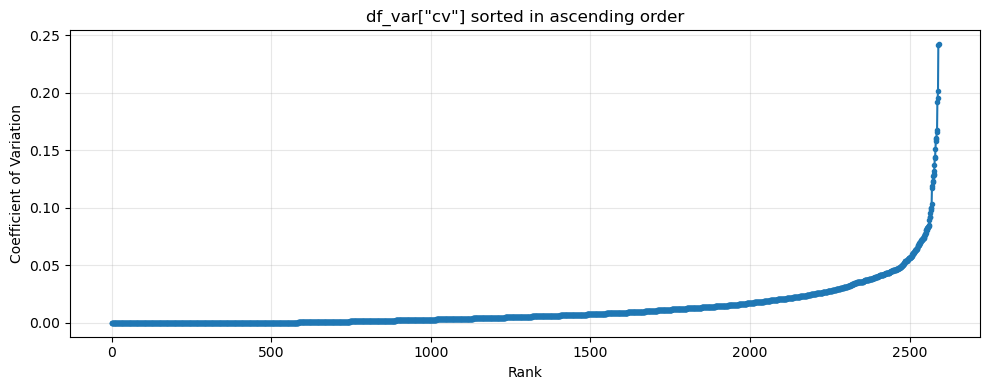

In [12]:
import matplotlib.pyplot as plt

cv_sorted = df_var['cv'].sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(cv_sorted, marker='o', linestyle='-', markersize=3)
plt.xlabel('Rank')
plt.ylabel('Coefficient of Variation')
plt.title('df_var["cv"] sorted in ascending order')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
df_var.describe()

,case_idx,mean_J,std_J,range_J,min_J,max_J,cv
count,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000
mean,1295.500000,0.851857,0.010303,0.044009,0.824186,0.868195,0.012533
std,748.390273,0.085940,0.015934,0.068783,0.101856,0.084103,0.020939
min,0.000000,0.402702,0.000000,0.000000,0.034417,0.402702,0.000000
25%,647.750000,0.820350,0.000463,0.002237,0.774259,0.841666,0.000541
50%,1295.500000,0.874008,0.004480,0.019151,0.851721,0.890012,0.005256
75%,1943.250000,0.910380,0.013104,0.059279,0.896160,0.922680,0.015340
max,2591.000000,0.993401,0.164111,0.734523,0.993401,0.993401,0.242092
